## Requirements

- **Python ≥ 3.11** — geopandas 1.x and fiona 1.10+ require Python 3.11+
- **Packages:** `pip install requests rasterio numpy matplotlib pystac-client geopandas pyproj pandas`
- **Network:** HTTP access to `kanopia.org` (STAC API) and `lab.kanopia.org` (COG files)
- **Credentials:** Basic Auth required for COG files — set `COG_USER` / `COG_PASS` in the config cell

# STAC Search by Spatial & Temporal Extent

Query the Kanopia STAC API using only a **bounding box** and a **date range** — no collection filter.

Use case: *find all RGB, DSM, and LAZ assets over global tropical forests between 2019 and 2025.*

---
**Steps**
1. Search the STAC API — bbox + datetime, no collection filter
2. Filter to RGB / DSM / COPC LAZ (exclude raw) and summarise by project

In [33]:
# ── Install packages (safe to re-run) ────────────────────────────────────────
import sys, subprocess
pkgs = ["requests", "rasterio", "numpy", "matplotlib",
        "pystac-client", "geopandas", "pyproj", "pandas"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
print("Packages ready.")

Packages ready.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
# ── Configuration ─────────────────────────────────────────────────────────────
STAC_API_URL = "https://kanopia.org/stac-fastapi-pgstac/api/v1/pgstac/"

# Workshop credentials
COG_USER = "panama"
COG_PASS = "panama123"

# ── Spatial extent: global tropical belt (Tropic of Cancer to Tropic of Capricorn) ─
# Covers all tropical forests worldwide: Amazon, Congo, SE Asia, Central America, etc.
BBOX = [-180, -23.5, 180, 23.5]

# ── Temporal extent: ISO-8601 interval ────────────────────────────────────────
DATETIME = "2019-01-01T00:00:00Z/2025-12-31T23:59:59Z"

MAX_ITEMS = 9999   # cap results; set to None for all

print(f"STAC endpoint : {STAC_API_URL}")
print(f"Bounding box  : {BBOX}  (global tropical belt)")
print(f"Date range    : {DATETIME}")

STAC endpoint : https://kanopia.org/stac-fastapi-pgstac/api/v1/pgstac/
Bounding box  : [-180, -23.5, 180, 23.5]  (global tropical belt)
Date range    : 2019-01-01T00:00:00Z/2025-12-31T23:59:59Z


In [35]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from pyproj import Transformer
from pystac_client import Client
from urllib.parse import urlparse, urlunparse

# Tune GDAL for remote reads
os.environ.setdefault("GDAL_HTTP_TIMEOUT",            "120")
os.environ.setdefault("GDAL_HTTP_MAX_RETRY",          "3")
os.environ.setdefault("GDAL_HTTP_RETRY_DELAY",        "5")
os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")

def add_auth(url, user, pwd):
    """Embed Basic Auth credentials into a URL."""
    p = urlparse(url)
    if p.username:
        return url
    netloc = f"{user}:{pwd}@{p.netloc}"
    return urlunparse((p.scheme, netloc, p.path, p.params, p.query, p.fragment))

print("Imports OK.")

Imports OK.


---
## Step 1 — Search by spatial + temporal extent

We pass `bbox` and `datetime` to the STAC search — **no `collections` filter**.
The API returns every item whose spatial footprint intersects the bounding box
and whose acquisition date falls within the date range.

In [36]:
# ── Step 1: STAC search — bbox + datetime, no collection filter ───────────────
client = Client.open(STAC_API_URL)

search = client.search(
    bbox=BBOX,
    datetime=DATETIME,
    max_items=MAX_ITEMS,
)

try:
    items = list(search.item_collection())
except AttributeError:
    items = list(search.get_all_items())  # fallback for older pystac-client

print(f"Found {len(items)} item(s) matching the spatial + temporal extent.")

Found 269 item(s) matching the spatial + temporal extent.


---
## Step 2 — Summary by project (collection)

Filter to **RGB**, **DSM**, and **LAZ** assets (exclude raw).  
Count assets per collection, with a grand total row.

  Assets: 1024  |  Collections: 19
                   RGB  DSM  LAZ  Total  first_date   last_date
2025_tiputini      104   52   50    206  2025-01-11  2025-12-16
2024_bci            80   40   38    158  2024-06-11  2025-10-21
2018_zf2_gaps       76   36    1    113  2019-04-05  2025-08-19
2023_aguasalud      46   23   22     91  2023-12-04  2025-06-25
2025_selvatek       44   22   22     88  2025-01-06  2025-11-03
2023_waponi         38   19   19     76  2022-09-24  2024-05-22
2024_tougas         24   12   12     48  2025-03-17  2025-03-20
2024_xprize         24   12   11     47  2024-05-19  2024-07-08
2024_panama         24   10   10     44  2024-07-24  2025-07-24
2023_tiputini       16    8    8     32  2023-05-25  2024-06-13
2024_danum          10    5    5     20  2024-11-21  2025-07-19
2025_manaus_pheno   10    5    5     20  2025-09-10  2025-11-18
2025_ducke          10    5    5     20  2024-11-08  2025-06-23
2025_dja            10    5    5     20  2025-03-07  2025-06-22
2024_

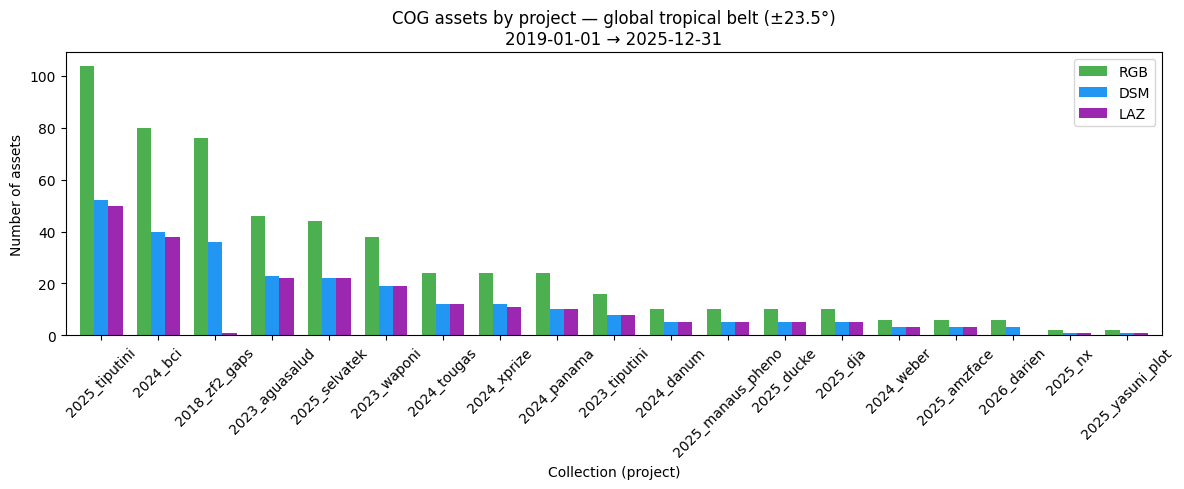

In [ ]:
# ── Step 2: Filter assets and summarise by project ────────────────────────────
import re

INCLUDE = re.compile(r"rgb.*\.cog\.tif|dsm.*\.cog\.tif|copc.*\.laz", re.I)
EXCLUDE = re.compile(r"raw|preview", re.I)

assets = []
for item in items:
    coll = getattr(item, "collection_id", None) or item.get("collection")
    dt   = getattr(item, "datetime",      None)
    if dt is None:
        props = getattr(item, "properties", {}) or item.get("properties", {})
        dt    = props.get("datetime") or props.get("start_datetime")
    item_assets = item.assets if hasattr(item, "assets") else item.get("assets", {})
    if not isinstance(item_assets, dict):
        continue
    for key, asset in item_assets.items():
        href  = asset.href if hasattr(asset, "href") else asset.get("href", "")
        label = f"{key} {href}"
        if not INCLUDE.search(label):
            continue
        if EXCLUDE.search(label):
            continue
        if re.search(r"copc|\.laz$", label, re.I):
            asset_type = "LAZ"
        elif re.search(r"dsm", label, re.I):
            asset_type = "DSM"
        else:
            asset_type = "RGB"
        assets.append({
            "collection": coll,
            "datetime":   str(dt)[:10] if dt else "?",
            "asset_type": asset_type,
        })

if not assets:
    print("No assets found — adjust BBOX or DATETIME and re-run.")
else:
    assets_df = pd.DataFrame(assets)

    summary = (
        assets_df
        .groupby(["collection", "asset_type"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["RGB", "DSM", "LAZ"], fill_value=0)
    )
    summary["Total"] = summary.sum(axis=1)
    summary = summary.sort_values("Total", ascending=False)

    # Date range per collection
    date_range = (
        assets_df
        .groupby("collection")["datetime"]
        .agg(first_date="min", last_date="max")
    )
    summary = summary.join(date_range)

    # Grand total row
    total_row = summary[["RGB", "DSM", "LAZ", "Total"]].sum().rename("TOTAL")
    summary_display = pd.concat([summary, total_row.to_frame().T])

    print("=" * 60)
    print(f"  Assets: {len(assets_df)}  |  Collections: {assets_df['collection'].nunique()}")
    print("=" * 60)
    print(summary_display.to_string())
    print()

    # Bar chart
    ax = summary[["RGB", "DSM", "LAZ"]].plot(
        kind="bar", figsize=(12, 5), width=0.75,
        color={"RGB": "#4caf50", "DSM": "#2196f3", "LAZ": "#9c27b0"},
    )
    ax.set_title(
        f"Geospatial assets by project — global tropical belt (±23.5°)\n"
        f"{DATETIME[:10]} → {DATETIME[21:31]}",
        fontsize=12,
    )
    ax.set_xlabel("Collection (project)")
    ax.set_ylabel("Number of assets")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()